<a href="https://colab.research.google.com/github/hareezzvijey/Amrita_AI_Research_Internship/blob/main/Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Logical Gate Visualization (AND, OR, XOR)

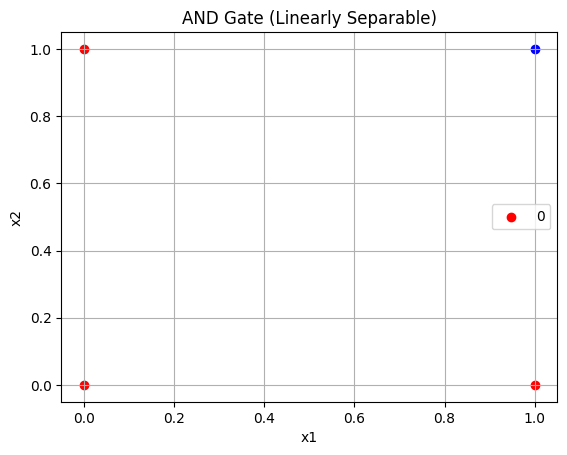

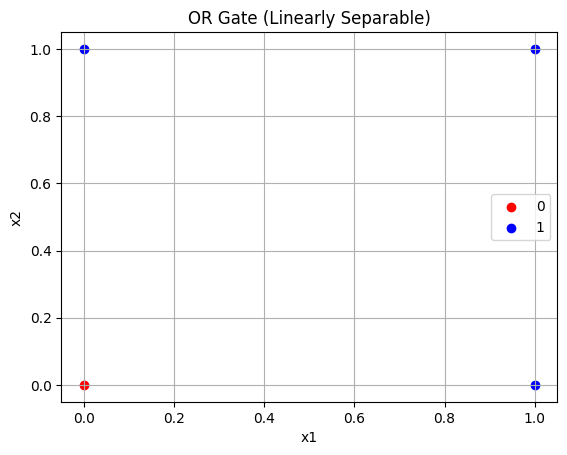

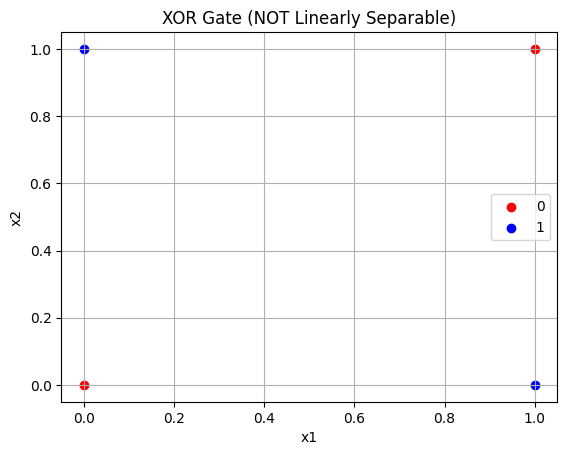

In [1]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

AND = np.array([0,0,0,1])
OR = np.array([0,1,1,1])
XOR = np.array([0,1,1,0])

def plot_gate(X, y, title):
    plt.figure()

    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], color='red', label='0' if i==0 else "")
        else:
            plt.scatter(X[i][0], X[i][1], color='blue', label='1' if i==1 else "")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid()

    plt.show()

plot_gate(X, AND, "AND Gate (Linearly Separable)")
plot_gate(X, OR, "OR Gate (Linearly Separable)")
plot_gate(X, XOR, "XOR Gate (NOT Linearly Separable)")

### 2. Single Layer Perceptron Implementation

In [7]:
w = np.random.randn(2)
print(w)

[-1.46239081  0.79914736]


In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Stochastic gradient descent
def train_perceptron(X, y, epochs=1000, lr=0.1):
    w = np.random.randn(2)
    b = 0

    for _ in range(epochs):
        for i in range(len(X)):
            z = np.dot(X[i], w) + b
            y_pred = sigmoid(z)

            error = y_pred - y[i]

            w -= lr * error * X[i]
            b -= lr * error

    return w, b

def plot_with_boundary(X, y, w, b, title):
    plt.figure()

    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], color='red')
        else:
            plt.scatter(X[i][0], X[i][1], color='blue')

    # Decision boundary: w1*x1 + w2*x2 + b = 0
    x_vals = np.linspace(-0.5, 1.5, 100)

    if w[1] != 0:
        y_vals = -(w[0]*x_vals + b) / w[1]
        plt.plot(x_vals, y_vals, color='green', label='Decision Boundary')

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid()
    plt.show()

AND

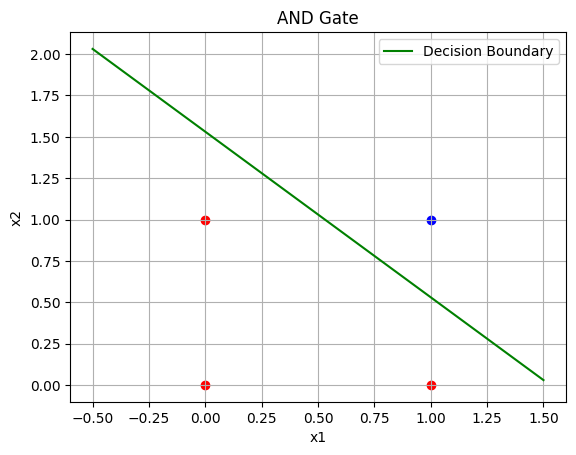

In [4]:
w_and, b_and = train_perceptron(X, AND)
plot_with_boundary(X, AND, w_and, b_and, "AND Gate")

OR

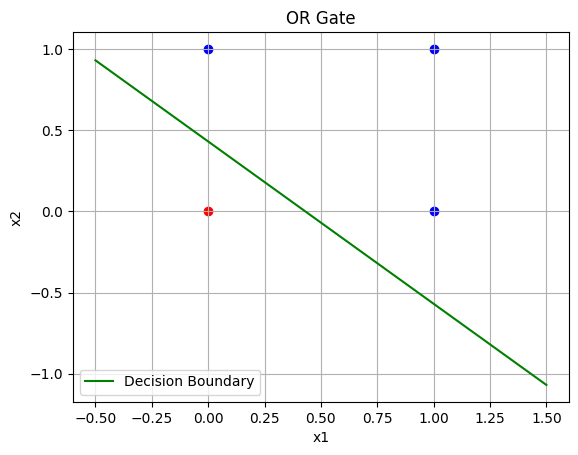

In [5]:
w_or, b_or = train_perceptron(X, OR)
plot_with_boundary(X, OR, w_or, b_or, "OR Gate")

XOR

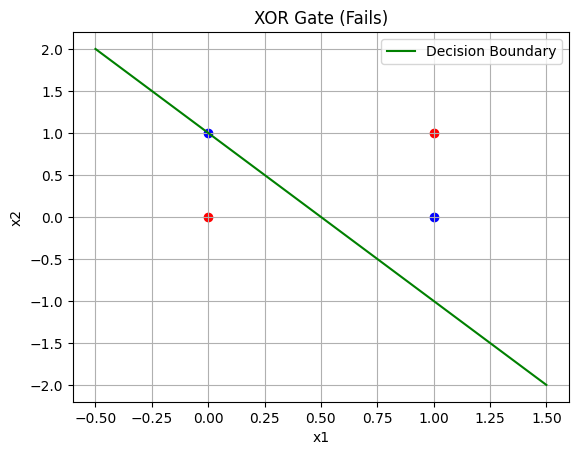

In [6]:
w_xor, b_xor = train_perceptron(X, XOR)
plot_with_boundary(X, XOR, w_xor, b_xor, "XOR Gate (Fails)")

### 3. Multi-Layer Perceptron (MLP)

In [23]:
import numpy as np

def sigmoid(X_input):
  return 1 / (1 + np.exp(-X_input))

def sigmoid_derivative(X_input):
  return X_input * (1 - X_input)

def train_mlp(X, y, epochs=10000, lr=0.1):

  # Input to hidden
  w1 = np.random.rand(2,2)
  b1 = np.zeros((1, 2))

  # hidden to output
  w2 = np.random.rand(2,1)
  b2 = np.zeros((1,1))

  for i in range(epochs):

    # Forward pass
    z1 = np.dot(X, w1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, w2) + b2
    y_pred = sigmoid(z2)

    loss = np.mean((y - y_pred)**2)

    # Backpropagation
    # Output layer
    error_output = y_pred - y
    d_output = error_output * sigmoid_derivative(y_pred)

    # Hidden layer
    error_hidden = np.dot(d_output, w2.T)
    d_hidden = error_hidden * sigmoid_derivative(a1)

    # Update weights and biases
    w2 -= lr * np.dot(a1.T, d_output)
    b2 -= lr * np.sum(d_output, axis=0, keepdims=True)

    w1 -= lr * np.dot(X.T, d_hidden)
    b1 -= lr * np.sum(d_hidden, axis=0, keepdims=True)

    if i % 1000 == 0:
        pass

  return w1, b1, w2, b2

def predict(X, w1, b1, w2, b2):
    a1 = sigmoid(np.dot(X, w1) + b1)
    y_pred = sigmoid(np.dot(a1, w2) + b2)
    return (y_pred > 0.5).astype(int)


# Input
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Gates
AND = np.array([[0],[0],[0],[1]])
OR  = np.array([[0],[1],[1],[1]])
XOR = np.array([[0],[1],[1],[0]])


print("AND:")
w1_and,b1_and,w2_and,b2_and = train_mlp(X, AND)
print(predict(X, w1_and,b1_and,w2_and,b2_and))

print("OR")
w1_or,b1_or,w2_or,b2_or = train_mlp(X, OR)
print(predict(X, w1_or,b1_or,w2_or,b2_or))

print("XOR:")
w1_xor,b1_xor,w2_xor,b2_xor = train_mlp(X, XOR)
print(predict(X, w1_xor,b1_xor,w2_xor,b2_xor))

AND:
[[0]
 [0]
 [0]
 [1]]
OR
[[0]
 [1]
 [1]
 [1]]
XOR:
[[0]
 [1]
 [1]
 [0]]


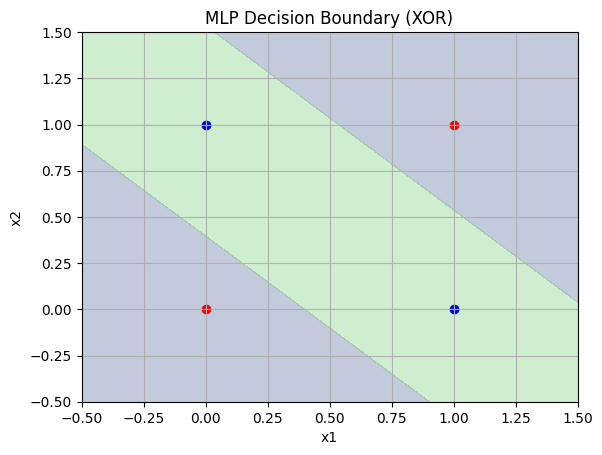

In [19]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])
W1, b1, W2, b2 = train_mlp(X, y)
def plot_boundary(W1, b1, W2, b2):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Forward pass
    a1 = sigmoid(np.dot(grid, W1) + b1)
    z2 = np.dot(a1, W2) + b2
    preds = sigmoid(z2)

    preds = preds.reshape(xx.shape)

    # Plot contour
    plt.contourf(xx, yy, preds, levels=[0,0.5,1], alpha=0.3)

    # Plot points
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], color='red')
        else:
            plt.scatter(X[i][0], X[i][1], color='blue')

    plt.title("MLP Decision Boundary (XOR)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid()
    plt.show()


plot_boundary(W1, b1, W2, b2)

### 4. Deep Neural Network for Sonar Dataset Classification

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('sonar_dataset.csv')
df.head(5)

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R


In [5]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
y = y.map({'R': 0, 'M': 1})

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(60, input_shape=(60,), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5379 - loss: 0.7185 - val_accuracy: 0.5152 - val_loss: 0.6722
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6894 - loss: 0.5658 - val_accuracy: 0.6364 - val_loss: 0.6196
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8106 - loss: 0.4601 - val_accuracy: 0.6061 - val_loss: 0.6014
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8258 - loss: 0.4086 - val_accuracy: 0.6364 - val_loss: 0.5738
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8712 - loss: 0.3460 - val_accuracy: 0.6667 - val_loss: 0.5550
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9015 - loss: 0.2888 - val_accuracy: 0.6667 - val_loss: 0.5458
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9394 - loss: 0.2640 - val_accuracy: 0.6970 - val_loss: 0.5167
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9167 - loss: 0.2523 - val_accuracy: 0.69

In [17]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6667 - loss: 1.8188
Test Accuracy: 0.6666666865348816


In [22]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


### 5. Model Optimization and Performance Tuning

In [44]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(60, activation='relu', input_shape=(60,),
        kernel_regularizer=tf.keras.regularizers.l2(0.001)),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(30, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[callback]
)

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5455 - loss: 0.8317 - val_accuracy: 0.4848 - val_loss: 0.8066
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6742 - loss: 0.6716 - val_accuracy: 0.6061 - val_loss: 0.7695
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.6206 - val_accuracy: 0.6667 - val_loss: 0.7383
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7955 - loss: 0.5387 - val_accuracy: 0.6364 - val_loss: 0.7162
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8106 - loss: 0.5021 - val_accuracy: 0.6364 - val_loss: 0.6843
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9015 - loss: 0.4351 - val_accuracy: 0.6970 - val_loss: 0.6641
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8939 - loss: 0.4022 - val_accuracy: 0.7273 - val_loss: 0.6562
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9242 - loss: 0.3672 - val_accuracy: 0.7576 - 

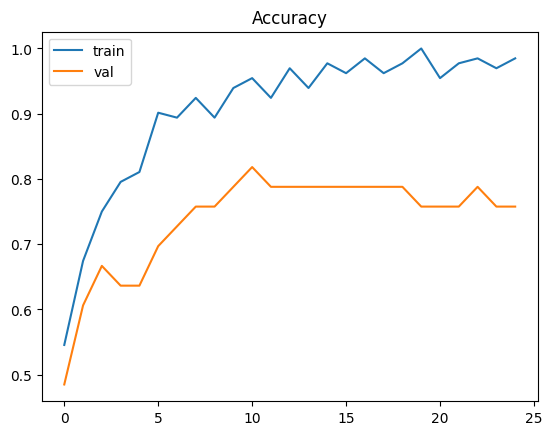

In [46]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

In [47]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7381 - loss: 0.7077
Test Accuracy: 0.738095223903656


Train ↑↑↑ (almost perfect)
Val   ↑ then ↓

👉 Classic pattern:

Model memorizing instead of learning

In [68]:
model = tf.keras.Sequential([
    # Increase the regularization to 0.001 -> 0.01
    tf.keras.layers.Dense(60, activation='tanh', input_shape=(60,),
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(27, activation='tanh',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

# # Simpler model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(30, activation='relu',
#         input_shape=(60,),
#         kernel_regularizer=tf.keras.regularizers.l2(0.01)),

#     tf.keras.layers.Dropout(0.5),

#     tf.keras.layers.Dense(1, activation='sigmoid')
# ])

# callback = tf.keras.callbacks.EarlyStopping(
#     monitor='val_loss',
#     patience=10,
#     restore_best_weights=True
# )

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [69]:
history = model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=8,
    validation_split=0.2,
    #callbacks=[callback]
)

Epoch 1/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6136 - loss: 1.5950 - val_accuracy: 0.5152 - val_loss: 1.6573
Epoch 2/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7879 - loss: 1.4131 - val_accuracy: 0.5152 - val_loss: 1.5866
Epoch 3/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8030 - loss: 1.2673 - val_accuracy: 0.6061 - val_loss: 1.5491
Epoch 4/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8561 - loss: 1.2021 - val_accuracy: 0.5758 - val_loss: 1.5118
Epoch 5/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8712 - loss: 1.1612 - val_accuracy: 0.6061 - val_loss: 1.4871
Epoch 6/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9015 - loss: 1.0799 - val_accuracy: 0.6061 - val_loss: 1.4447
Epoch 7/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9015 - loss: 1.0291 - val_accuracy: 0.6061 - val_loss: 1.4181
Epoch 8/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8788 - loss: 0.9782 - val_accuracy: 0.6970 - 

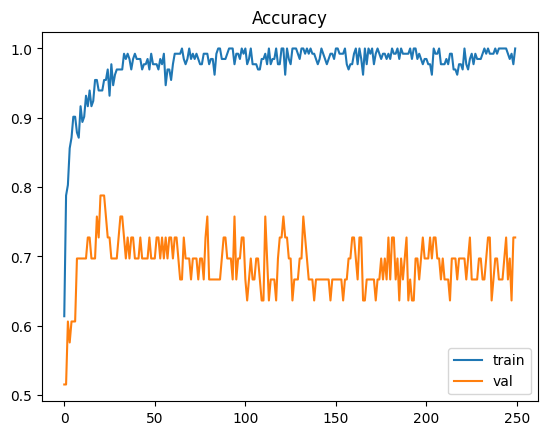

In [70]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

In [71]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6667 - loss: 2.6575
Test Accuracy: 0.6666666865348816


### 6. Feature Reduction Experiment (60 → 30)

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=30)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation='tanh', input_shape=(30,), # Changed input_shape from 60 to 30
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(15, activation='tanh', # Adjusted number of neurons for the second layer
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=8,
    validation_split=0.2,
    callbacks=[callback]
)

Epoch 1/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.4848 - loss: 1.2869 - val_accuracy: 0.4545 - val_loss: 1.2950
Epoch 2/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5985 - loss: 1.1375 - val_accuracy: 0.6061 - val_loss: 1.1793
Epoch 3/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7424 - loss: 1.0007 - val_accuracy: 0.6667 - val_loss: 1.1173
Epoch 4/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8106 - loss: 0.9447 - val_accuracy: 0.6364 - val_loss: 1.0740
Epoch 5/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7803 - loss: 0.9093 - val_accuracy: 0.6364 - val_loss: 1.0407
Epoch 6/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8030 - loss: 0.8479 - val_accuracy: 0.6364 - val_loss: 1.0084
Epoch 7/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7879 - loss: 0.8296 - val_accuracy: 0.6364 - val_loss: 0.9749
Epoch 8/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7803 - loss: 0.8335 - val_accuracy: 0.6

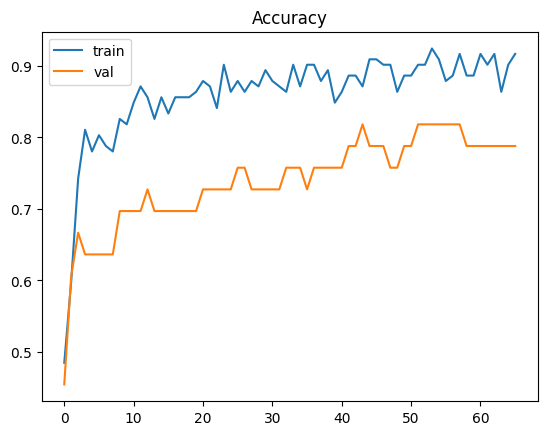

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

In [14]:
loss, acc = model.evaluate(X_test, y_test)
print(acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7619 - loss: 0.7261
0.761904776096344


### 7. Feature Reduction Experiment (30 → 20)

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=20)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, activation='tanh', input_shape=(20,),
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='tanh',
        kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=250,
    batch_size=8,
    validation_split=0.2,
    callbacks=[callback]
)

Epoch 1/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7273 - loss: 0.9075 - val_accuracy: 0.6667 - val_loss: 0.9226
Epoch 2/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7652 - loss: 0.8738 - val_accuracy: 0.6970 - val_loss: 0.8995
Epoch 3/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7576 - loss: 0.8332 - val_accuracy: 0.7273 - val_loss: 0.8818
Epoch 4/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8106 - loss: 0.7935 - val_accuracy: 0.7273 - val_loss: 0.8670
Epoch 5/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7955 - loss: 0.7709 - val_accuracy: 0.7273 - val_loss: 0.8520
Epoch 6/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7879 - loss: 0.7503 - val_accuracy: 0.7273 - val_loss: 0.8360
Epoch 7/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8030 - loss: 0.7298 - val_accuracy: 0.7273 - val_loss: 0.8216
Epoch 8/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7879 - loss: 0.7144 - val_accuracy: 0.72

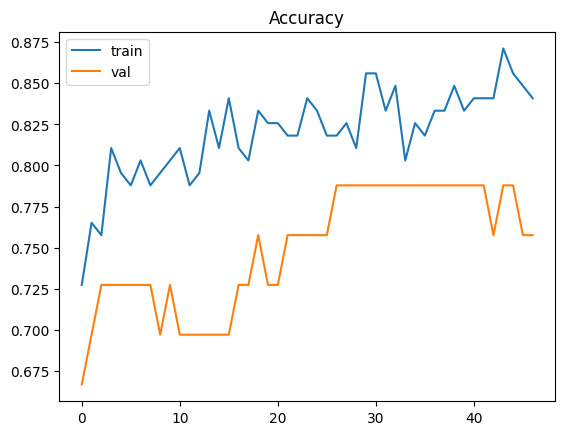

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.title("Accuracy")
plt.show()

In [20]:
loss, acc = model.evaluate(X_test, y_test)
print(acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7619 - loss: 0.7104
0.761904776096344
